In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import PolynomialFeatures 
import matplotlib.pyplot as plt

In [2]:
# Se cargan los datos. 

data=pd.read_csv('car_details_v3.csv',sep=',')

In [3]:
# Mostrar los datos

data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [4]:
# Cantidad de datos y número de variables

data.shape

(8128, 13)

In [5]:
data.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [6]:
# Es recomendable que todos los pasos preparación se realicen sobre otro archivo.

data_t = data

In [7]:
data_t=data_t.dropna()
data_t=data_t.drop_duplicates()

data_t['mileage'] = data_t['mileage'].astype(str).str.extract(r'([\d.]+)').astype(float)
data_t['mileage'] = pd.to_numeric(data_t['mileage'], errors='coerce')
data_t['engine'] = data_t['engine'].astype(str).str.extract(r'([\d.]+)').astype(float)
data_t['engine'] = pd.to_numeric(data_t['engine'], errors='coerce')
data_t['max_power'] = data_t['max_power'].astype(str).str.extract(r'([\d.]+)').astype(float)
data_t['max_power'] = pd.to_numeric(data_t['max_power'], errors='coerce')

data_t.shape

(6717, 13)

In [8]:
data_t.describe()

,year,selling_price,km_driven,mileage,engine,max_power,seats
count,6717.000000,6.717000e+03,6.717000e+03,6717.000000,6717.000000,6717.000000,6717.000000
mean,2013.611136,5.263860e+05,7.339834e+04,19.466585,1430.985857,87.766100,5.434271
std,3.897402,5.235504e+05,5.870328e+04,4.048102,493.469198,31.724555,0.983805
min,1994.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,32.800000,2.000000
25%,2011.000000,2.500000e+05,3.800000e+04,16.800000,1197.000000,67.100000,5.000000
50%,2014.000000,4.200000e+05,6.820300e+04,19.440000,1248.000000,81.830000,5.000000
75%,2017.000000,6.500000e+05,1.000000e+05,22.500000,1498.000000,100.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,14.000000


In [9]:
data_t.head(5)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0


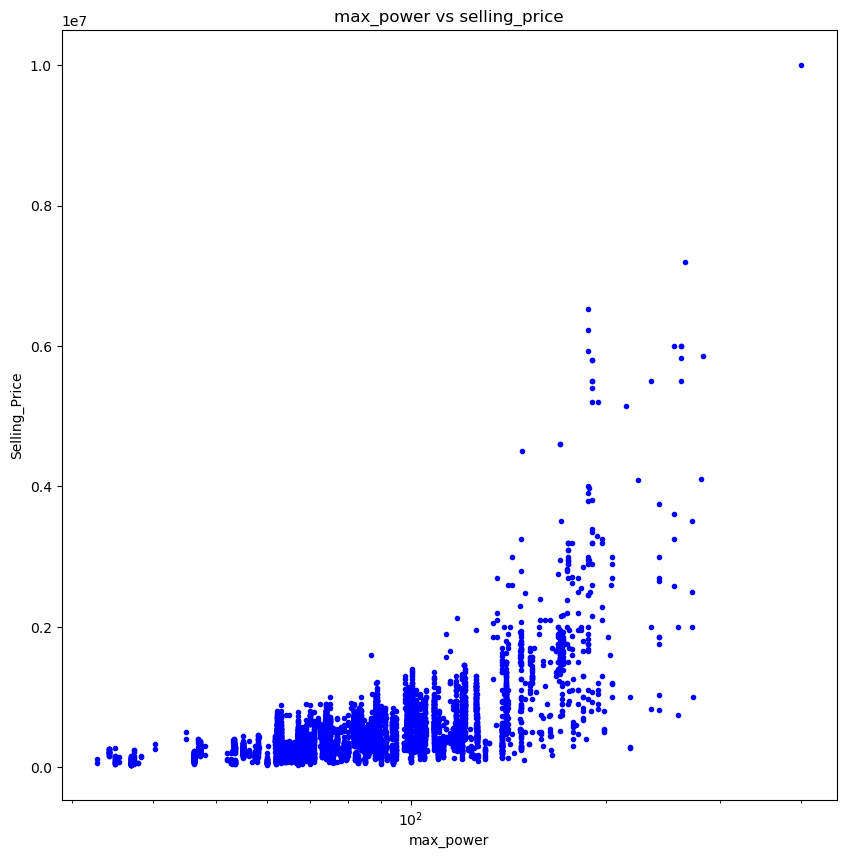

In [56]:
# Generamos un gráfico de dispersión, que nos permitirá ver la relación entre las dos variables.

plt.figure(figsize=(10,10))
plt.plot(data_t['max_power'],data_t['selling_price'],'.', color='blue')
plt.title('max_power vs selling_price')
plt.xlabel('max_power')  
plt.xscale('log')
plt.ylabel('Selling_Price')  
plt.show()

In [15]:
# Eliminación de columnas que no buscamos modelar en la regresion.

data_t=data_t.drop(['name'], axis=1)
data_t=data_t.drop(['seller_type'], axis=1)
data_t=data_t.drop(['transmission'], axis=1)
data_t=data_t.drop(['torque'], axis=1)
data_t=data_t.drop(['fuel'], axis=1)
data_t=data_t.drop(['owner'], axis=1)
data_t=data_t.drop(['km_driven'], axis=1)
data_t=data_t.drop(['mileage'], axis=1)
data_t=data_t.drop(['engine'], axis=1)
#data_t=data_t.drop(['max_power'], axis=1)
data_t=data_t.drop(['seats'], axis=1)
data_t=data_t.drop(['year'], axis=1)

In [16]:
# Se selecciona la variable objetivo, en este caso "precio".

Y=data_t['selling_price']
X=data_t.drop(['selling_price'], axis=1)

In [17]:
# Mostramos nuestros datos

X.head()

,max_power
0,74.00
1,103.52
2,78.00
3,90.00
4,88.20


In [18]:
Y.head()

0    450000
1    370000
2    158000
3    225000
4    130000
Name: selling_price, dtype: int64

In [19]:
# Se realiza la división entrenamiento - test. Se deja 20% de los datos para el test.

X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size=0.2, random_state=0)

In [20]:
# Primero se crea el objeto para construir el modelo

modelo_regresion = LinearRegression()
modelo_regresion

LinearRegression()

In [21]:
# Ajustar el modelo con los datos de entrenamiento

modelo_regresion.fit(X_train,Y_train)

LinearRegression()

In [22]:
# Se obtienen las predicciones del modelo sobre el conjunto test.

y_pred = modelo_regresion.predict(X_test)

mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)   
mae = mean_absolute_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print("MSE: %.2f" % mse)
print("RMSE: %.2f" % rmse)
print("MAE: %.2f" % mae)
print("R²: %.2f" % r2)

MSE: 165289774571.31
RMSE: 406558.45
MAE: 223770.93
R²: 0.48


In [23]:
# Podemos visualizar los parámetros del modelo (coeficientes de regresión)

modelo_regresion.coef_

array([11213.1723838])

In [24]:
# Para visualizar el intercepto, utiliza el atributo intercept_ del modelo

float(modelo_regresion.intercept_)

-459977.1948886855

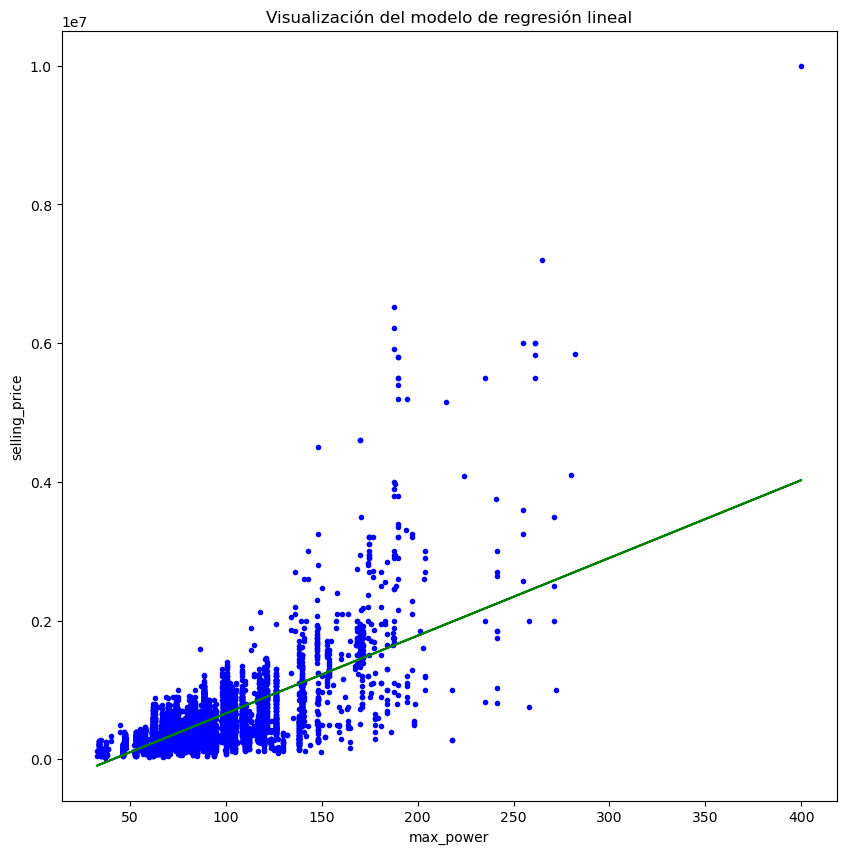

In [57]:
plt.figure(figsize=(10,10))
plt.title('Visualización del modelo de regresión lineal')
plt.xlabel('max_power') 
plt.ylabel('selling_price')  

w1 = modelo_regresion.coef_[0]
w0 = modelo_regresion.intercept_

plt.plot(X, Y,'.', color='blue')
plt.plot(X, w0 + w1*X, color ='green')
plt.show()

In [28]:
# Se indica el grado de la transformación. 

pf = PolynomialFeatures(degree = 2) 

In [29]:
# Se aplica la transformación a los datos.

X_pol = pf.fit_transform(X)  

In [30]:
# Se muestran los datos transformados.

X_pol

array([[1.00000000e+00, 7.40000000e+01, 5.47600000e+03],
       [1.00000000e+00, 1.03520000e+02, 1.07163904e+04],
       [1.00000000e+00, 7.80000000e+01, 6.08400000e+03],
       ...,
       [1.00000000e+00, 8.28500000e+01, 6.86412250e+03],
       [1.00000000e+00, 1.10000000e+02, 1.21000000e+04],
       [1.00000000e+00, 7.39000000e+01, 5.46121000e+03]])

In [31]:
# Se realiza la división entrenamiento - test. Se deja 20% de los datos para el test.  Como estamos utilizando el mismo
# valor para random_state (=0) garantizamos que obtenemos la misma partición utilizada para el modelo anterior.

X_train, X_test, Y_train, Y_test = train_test_split(X_pol, Y, test_size=0.2, random_state=0)

In [32]:
# Creación del objeto de la clase LinearRegression y ajuste del modelo a los datos.

modelo_reg_polinomial = LinearRegression().fit(X_train, Y_train)

In [33]:
# Se obtienen las predicciones del modelo sobre el conjunto test.

y_pred = modelo_reg_polinomial.predict(X_test)

mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)   
mae = mean_absolute_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print("MSE: %.2f" % mse)
print("RMSE: %.2f" % rmse)
print("MAE: %.2f" % mae)
print("R²: %.2f" % r2)

MSE: 139962329385.33
RMSE: 374115.40
MAE: 214142.67
R²: 0.56


In [34]:
# Parámetros del modelo (coeficientes de regresión e intercepto)
print ('Coeficientes: ', modelo_reg_polinomial.coef_)
print ('Intercepto: ',modelo_reg_polinomial.intercept_)

Coeficientes:  [    0.         -2771.75441863    60.98779056]
Intercepto:  237571.5272638389


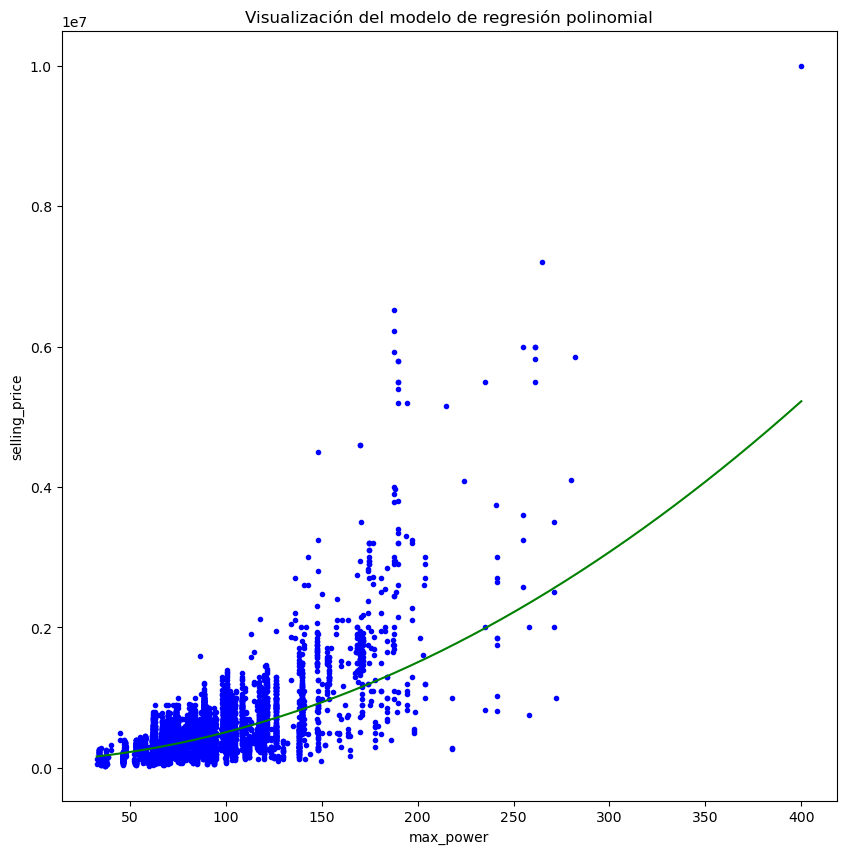

In [58]:
plt.figure(figsize=(10,10))
plt.title('Visualización del modelo de regresión polinomial')
plt.xlabel('max_power')  
plt.ylabel('selling_price')  

w1 = modelo_reg_polinomial.coef_[1]
w2 = modelo_reg_polinomial.coef_[2]
w0 = modelo_reg_polinomial.intercept_

plt.plot(X, Y,'.', color='blue')

puntos = np.linspace(X.min(), X.max(), 500)
modelo = w0 + w1*puntos + w2*(puntos**2)

plt.plot(puntos, modelo , color ='green')
plt.show()

In [47]:
# Se indica el grado de la transformación. 

pf = PolynomialFeatures(degree = 3) 

In [48]:
# Se aplica la transformación a los datos.

X_pol = pf.fit_transform(X)  

In [49]:
# Se muestran los datos transformados.

X_pol

array([[1.00000000e+00, 7.40000000e+01, 5.47600000e+03, 4.05224000e+05],
       [1.00000000e+00, 1.03520000e+02, 1.07163904e+04, 1.10936073e+06],
       [1.00000000e+00, 7.80000000e+01, 6.08400000e+03, 4.74552000e+05],
       ...,
       [1.00000000e+00, 8.28500000e+01, 6.86412250e+03, 5.68692549e+05],
       [1.00000000e+00, 1.10000000e+02, 1.21000000e+04, 1.33100000e+06],
       [1.00000000e+00, 7.39000000e+01, 5.46121000e+03, 4.03583419e+05]])

In [50]:
# Se realiza la división entrenamiento - test. Se deja 20% de los datos para el test.  Como estamos utilizando el mismo
# valor para random_state (=0) garantizamos que obtenemos la misma partición utilizada para el modelo anterior.

X_train, X_test, Y_train, Y_test = train_test_split(X_pol, Y, test_size=0.2, random_state=0)

In [51]:
# Creación del objeto de la clase LinearRegression y ajuste del modelo a los datos.

modelo_reg_polinomial = LinearRegression().fit(X_train, Y_train)

In [53]:
# Se obtienen las predicciones del modelo sobre el conjunto test.
y_pred = modelo_reg_polinomial.predict(X_test)

mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)   
mae = mean_absolute_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print("MSE: %.2f" % mse)
print("RMSE: %.2f" % rmse)
print("MAE: %.2f" % mae)
print("R²: %.2f" % r2)

MSE: 139525095041.80
RMSE: 373530.58
MAE: 212257.78
R²: 0.56


In [54]:
# # Parámetros del modelo (coeficientes de regresión e intercepto)

print ('Coeficientes: ', modelo_reg_polinomial.coef_)
print ('Intercepto: ',modelo_reg_polinomial.intercept_)

Coeficientes:  [0.00000000e+00 1.31328789e+03 2.88036301e+01 7.20916646e-02]
Intercepto:  87474.05190024641


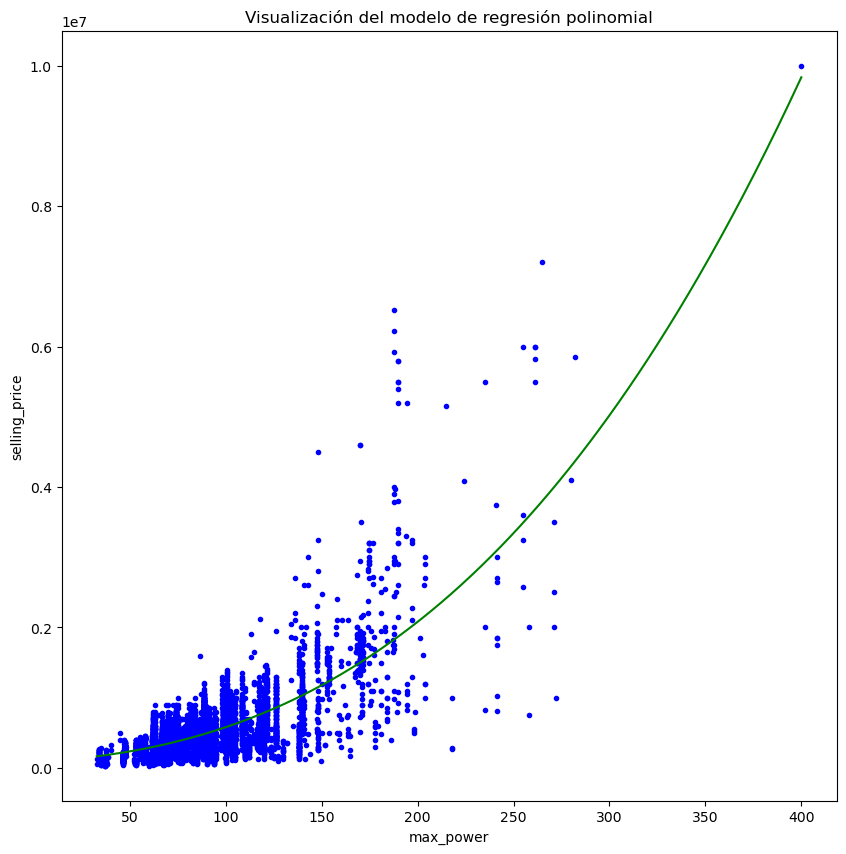

In [59]:
plt.figure(figsize=(10,10))
plt.title('Visualización del modelo de regresión polinomial')
plt.xlabel('max_power')  
plt.ylabel('selling_price')  

w1 = modelo_reg_polinomial.coef_[1]
w2 = modelo_reg_polinomial.coef_[2]
w3 = modelo_reg_polinomial.coef_[3]
w0 = modelo_reg_polinomial.intercept_

plt.plot(X, Y,'.', color='blue')

puntos = np.linspace(X.min(), X.max(), 500)
modelo = w0 + w1*puntos + w2*puntos**2 + w3*puntos**3

plt.plot(puntos, modelo , color ='green')
plt.show()